In [16]:
import xarray as xr
dt = xr.open_dataset("/glade/derecho/scratch/bgong/amip_s2s_ensembles/20190509/ensemble_20190509_seed0.nc")

In [41]:
dt["plev"]

<xarray.DataArray 'plev' (plev: 26)> Size: 208B
array([   500.,    700.,   1000.,   2000.,   3000.,   5000.,   7000.,  10000.,
        12500.,  15000.,  17500.,  20000.,  25000.,  30000.,  40000.,  50000.,
        60000.,  70000.,  80000.,  85000.,  87500.,  90000.,  92500.,  95000.,
        97500., 100000.])
Coordinates:
  * plev     (plev) float64 208B 500.0 700.0 1e+03 ... 9.5e+04 9.75e+04 1e+05
Attributes:
    units:          Pa
    standard_name:  air_pressure
    long_name:      pressure
    axis:           Z
    positive:       down

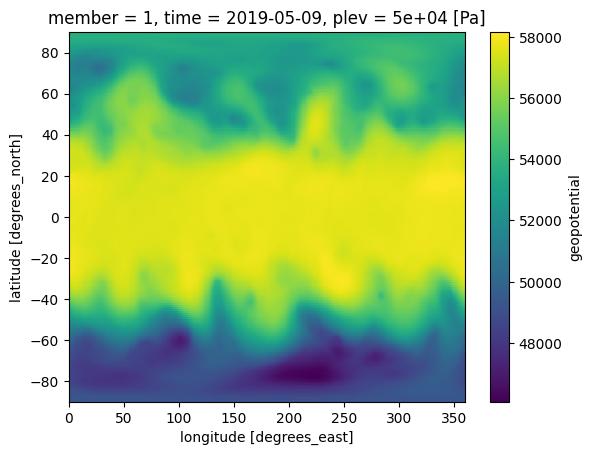

In [36]:
dt["geopotential"].sel(plev =50000).isel(time=0,member=1).plot()

In [35]:
variable = "geopotential"
variable_fcst = "geopotential"
era5 = xr.open_mfdataset(
    f"/glade/derecho/scratch/bgong/era5/{variable}/*_180x360.nc",
    chunks={},
    engine="netcdf4",
).rename({"lat": "latitude", "lon": "longitude"})

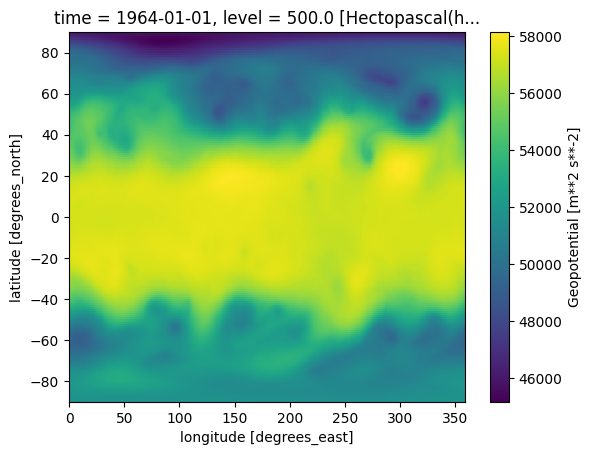

In [ ]:
era5["geopotential"].sel(level=500).isel(time=0).plot()


In [39]:
era5 = era5.rename({"latitude": "lat", "longitude": "lon"})

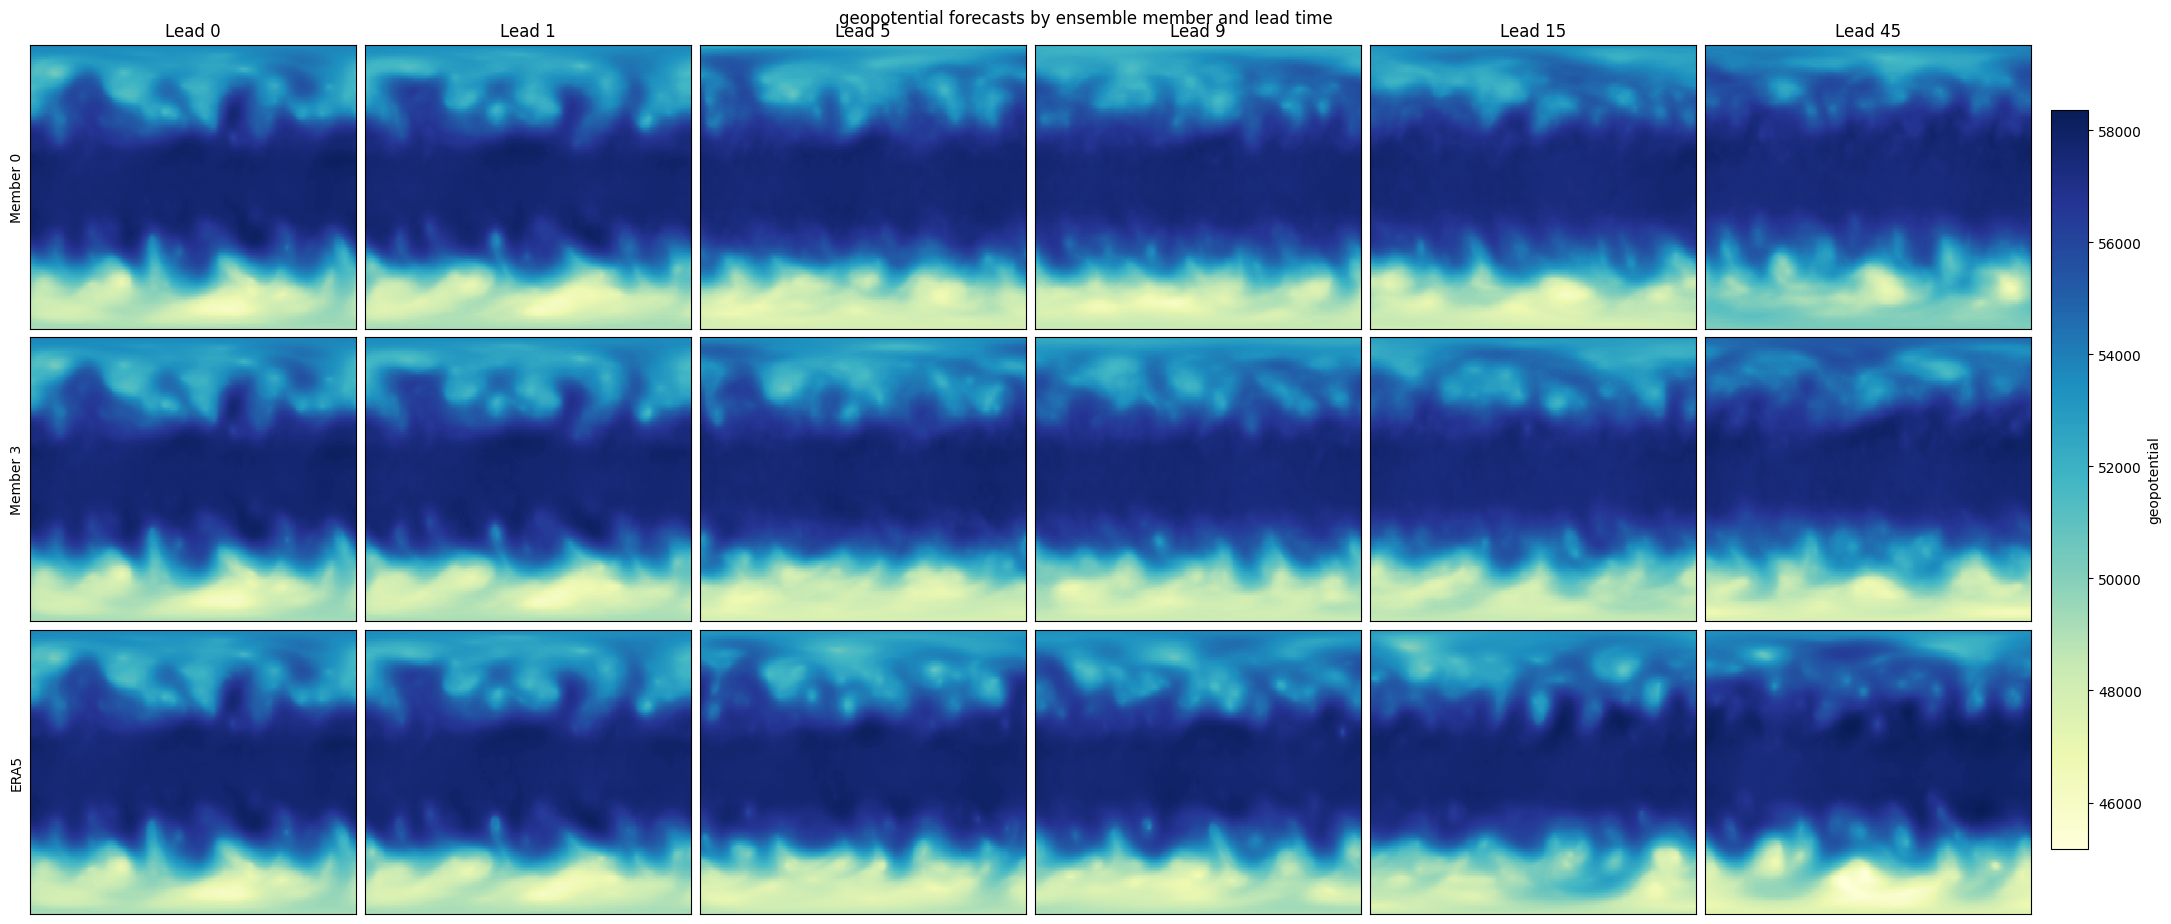

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

lead_times = [0, 1, 5, 9, 15, 45]
ensemble_members = [0,3]

fcst = dt["geopotential"].sel(plev=50000) 
truth = era5["geopotential"].sel(level=500) 


def find_name(obj, candidates):
    for name in obj.dims:
        if name.lower() in candidates:
            return name
    for name in obj.coords:
        if name.lower() in candidates:
            return name
    return None


lat_name = find_name(fcst, {"lat", "latitude"}) or find_name(truth, {"lat", "latitude"})
lon_name = find_name(fcst, {"lon", "longitude"}) or find_name(truth, {"lon", "longitude"})
member_name = find_name(fcst, {"member", "number", "ensemble", "ens"})
lead_name = find_name(fcst, {"time", "valid_time", "lead_time", "step", "forecast_hour"})
truth_time_name = find_name(truth, {"time", "valid_time"})

if member_name is None:
    raise ValueError(f"Could not find an ensemble dimension in forecast dims {fcst.dims}")
if lead_name is None:
    raise ValueError(f"Could not find a lead-time dimension in forecast dims {fcst.dims}")
if lat_name is None or lon_name is None:
    raise ValueError("Could not find latitude/longitude dimensions in the forecast or ERA5 data")
if truth_time_name is None:
    raise ValueError(f"Could not find a time dimension in ERA5 dims {truth.dims}")

if fcst.sizes[member_name] < 4:
    raise ValueError(f"Expected at least 4 ensemble members, found {fcst.sizes[member_name]}")
if fcst.sizes[lead_name] <= max(lead_times):
    raise ValueError(
        f"Forecast lead axis '{lead_name}' has size {fcst.sizes[lead_name]}, which is too small for lead times {lead_times}"
    )

selected_forecasts = []
selected_truths = []

for lead in lead_times:
    forecast_lead = fcst.isel({lead_name: lead}).squeeze(drop=True)
    selected_forecasts.append(forecast_lead)

    forecast_time = forecast_lead.coords.get(lead_name, None)
    if forecast_time is None:
        forecast_time = fcst[lead_name].isel({lead_name: lead}).values
    else:
        forecast_time = forecast_time.values

    truth_lead = truth.sel({truth_time_name: forecast_time}, method="nearest")
    selected_truths.append(truth_lead.squeeze(drop=True))

all_fields = []

for forecast_lead, truth_lead in zip(selected_forecasts, selected_truths):
    for member in ensemble_members:
        all_fields.append(forecast_lead.isel({member_name: member}).values )
    all_fields.append(truth_lead.values)

vmin = np.nanmin([np.nanmin(field) for field in all_fields])
vmax = np.nanmax([np.nanmax(field) for field in all_fields])
# vmin = 0.0
# vmax = 0.3

row_labels = [f"Member {m}" for m in ensemble_members] + ["ERA5"]

fig, axes = plt.subplots(
    len(ensemble_members) + 1,
    len(lead_times),
    figsize=(3.6 * len(lead_times), 3.0 * (len(ensemble_members) + 1)),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

for ax, lead in zip(axes[0], lead_times):
    ax.set_title(f"Lead {lead}")

mesh = None
for col, (lead, forecast_lead, truth_lead) in enumerate(zip(lead_times, selected_forecasts, selected_truths)):
    for row, member in enumerate(ensemble_members):
        ax = axes[row, col]
        field = forecast_lead.isel({member_name: member}).squeeze(drop=True)
        mesh = ax.pcolormesh(
            field[lon_name],
            field[lat_name],
            field,
            shading="auto",
            cmap="YlGnBu",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_labels[row])

    ax = axes[-1, col]
    mesh = ax.pcolormesh(
        truth_lead[lon_name],
        truth_lead[lat_name],
        truth_lead,
        shading="auto",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    if col == 0:
        ax.set_ylabel(row_labels[-1])

cbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), shrink=0.85, pad=0.01)
cbar.set_label(variable)
fig.suptitle(f"{variable} forecasts by ensemble member and lead time", y=1.01)
plt.show()
